In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_MAP = {
    "MILP": "MILP_forecast_RF_one_year.csv",
    "HeurTime": "HeurTime_forecast_RF_one_year.csv",
    "HeurQuantile": "HeurQuantile_forecast_RF_one_year.csv",
    "RL-PPO": "rlPPO_forecast_RF_one_year.csv",
    "GPT4": "gpt4_hourly_arbitrage_corrected3.csv",
}

In [2]:
def month_to_season(month: int) -> str:
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

In [3]:
def prepare_result_df(path, method_name, test_dates=None, start_date=None):
    """
    Convert an hourly result CSV into an hourly dataframe with:
    method, day_index, hour, date, weekday_name, is_weekend, season

    Prefer passing test_dates from your notebook.
    """
    df = pd.read_csv(path).copy()

    if "day" in df.columns:
        df["day_index"] = df["day"].astype(int)
    else:
        df["day_index"] = np.arange(len(df)) // 24

    df["hour"] = np.arange(len(df)) % 24
    n_days = df["day_index"].nunique()

    if test_dates is not None:
        if len(test_dates) != n_days:
            raise ValueError(f"len(test_dates)={len(test_dates)} but file has {n_days} days")
        day_to_date = {i: pd.to_datetime(test_dates[i]) for i in range(n_days)}
        df["date"] = df["day_index"].map(day_to_date)
    elif start_date is not None:
        date_range = pd.date_range(start=start_date, periods=n_days, freq="D")
        day_to_date = {i: date_range[i] for i in range(n_days)}
        df["date"] = df["day_index"].map(day_to_date)
    else:
        raise ValueError("Pass either test_dates or start_date")

    df["weekday_name"] = df["date"].dt.day_name()
    df["is_weekend"] = df["date"].dt.weekday >= 5
    df["regime_week"] = np.where(df["is_weekend"], "Weekend", "Weekday")
    df["month"] = df["date"].dt.month
    df["season"] = df["month"].apply(month_to_season)
    df["method"] = method_name

    return df

In [4]:
def make_daily_profit_df(hourly_df):
    """
    Aggregate hourly profit_step into day-level profit.
    """
    daily_df = (
        hourly_df.groupby(
            ["method", "day_index", "date", "weekday_name", "regime_week", "season"],
            as_index=False
        )
        .agg(
            day_profit=("profit_step", "sum"),
            mean_hourly_profit=("profit_step", "mean"),
        )
    )
    return daily_df

In [5]:
def summarize_weekend_weekday(daily_df):
    summary = (
        daily_df.groupby(["method", "regime_week"], as_index=False)
        .agg(
            n_days=("day_profit", "count"),
            mean_day_profit=("day_profit", "mean"),
            std_day_profit=("day_profit", "std"),
            median_day_profit=("day_profit", "median"),
            p5_day_profit=("day_profit", lambda x: np.quantile(x, 0.05)),
            total_profit=("day_profit", "sum"),
        )
    )
    return summary

In [6]:
def summarize_seasons(daily_df):
    summary = (
        daily_df.groupby(["method", "season"], as_index=False)
        .agg(
            n_days=("day_profit", "count"),
            mean_day_profit=("day_profit", "mean"),
            std_day_profit=("day_profit", "std"),
            median_day_profit=("day_profit", "median"),
            p5_day_profit=("day_profit", lambda x: np.quantile(x, 0.05)),
            total_profit=("day_profit", "sum"),
        )
    )
    return summary

In [7]:
all_hourly = []
all_daily = []

for method, path in FILE_MAP.items():
    hourly_df = prepare_result_df(path, method_name=method, start_date="2019-01-01")
    daily_df = make_daily_profit_df(hourly_df)

    all_hourly.append(hourly_df)
    all_daily.append(daily_df)

hourly_all = pd.concat(all_hourly, ignore_index=True)
daily_all = pd.concat(all_daily, ignore_index=True)

week_summary = summarize_weekend_weekday(daily_all)
season_summary = summarize_seasons(daily_all)

week_summary

,method,regime_week,n_days,mean_day_profit,std_day_profit,median_day_profit,p5_day_profit,total_profit
0,GPT4,Weekday,260,1666.914692,595.046394,1681.230000,615.522000,433397.820000
1,GPT4,Weekend,104,1678.466250,529.945048,1713.330000,650.856500,174560.490000
2,HeurQuantile,Weekday,260,1266.768702,548.392872,1281.216201,396.493999,329359.862469
3,HeurQuantile,Weekend,104,1285.137089,496.354283,1319.781938,308.534376,133654.257205
4,HeurTime,Weekday,260,1276.575546,336.284051,1239.088933,751.234341,331909.641982
5,HeurTime,Weekend,104,1128.322056,327.693821,1074.525912,606.407202,117345.493864
6,MILP,Weekday,260,1789.263750,363.154640,1745.600581,1249.494375,465208.574892
7,MILP,Weekend,104,1642.484077,348.557618,1606.838119,1142.528221,170818.344032
8,RL-PPO,Weekday,260,1577.677741,404.180537,1521.819670,986.908532,410196.212532
9,RL-PPO,Weekend,104,1509.732268,373.328896,1482.867228,986.388304,157012.155825


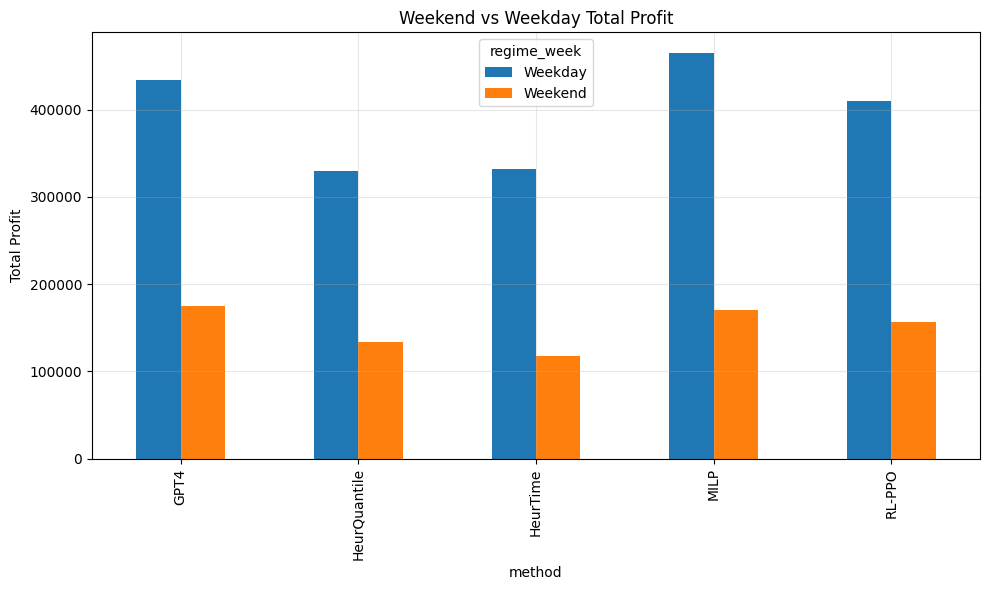

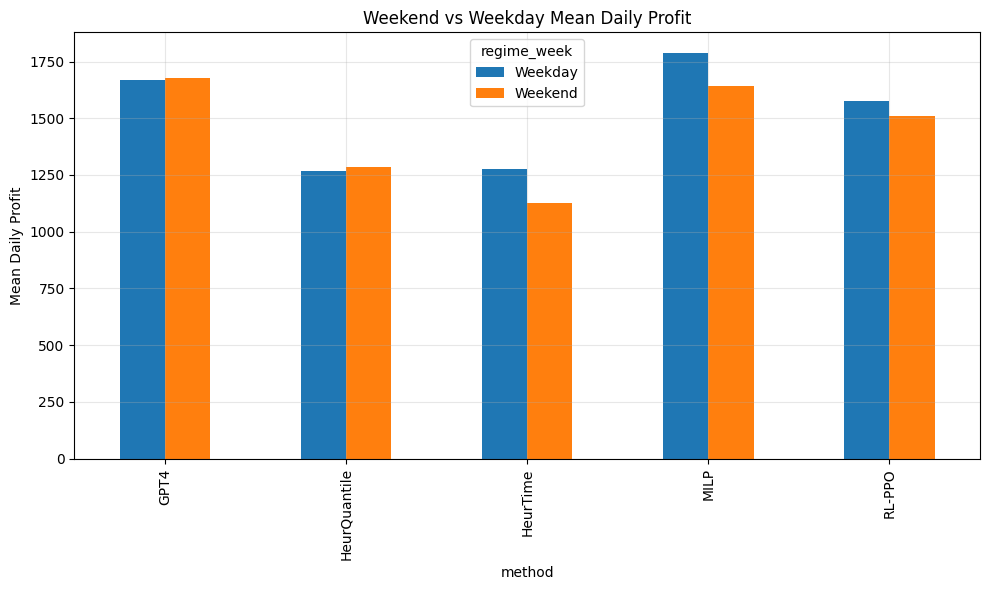

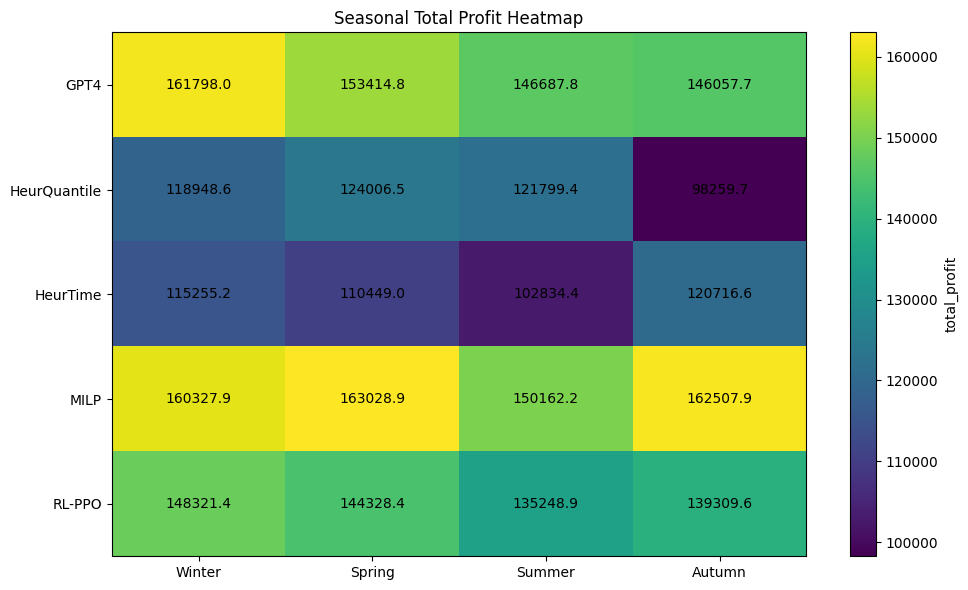

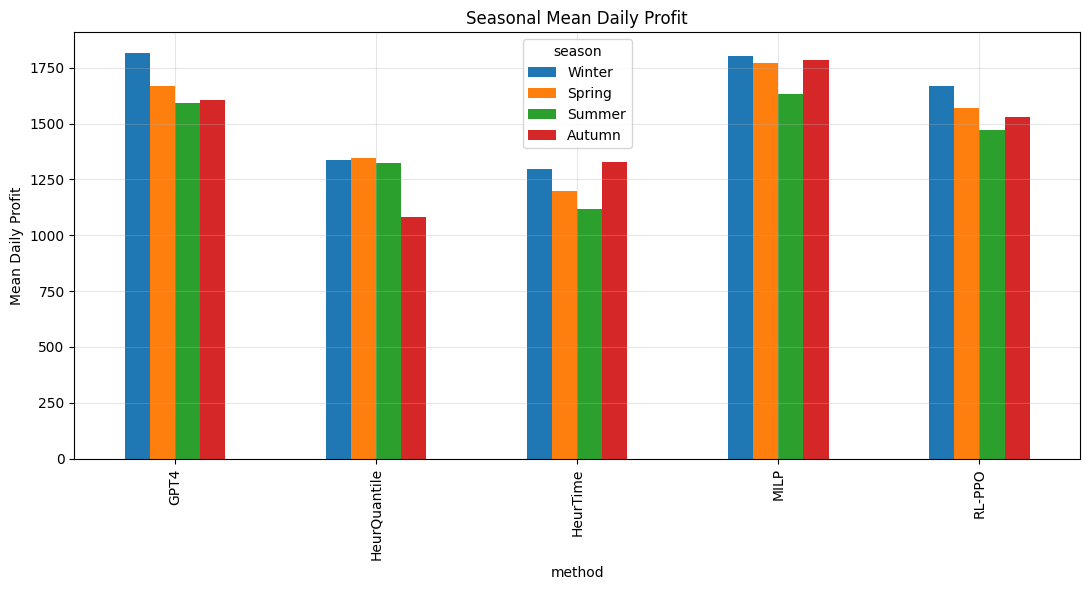

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


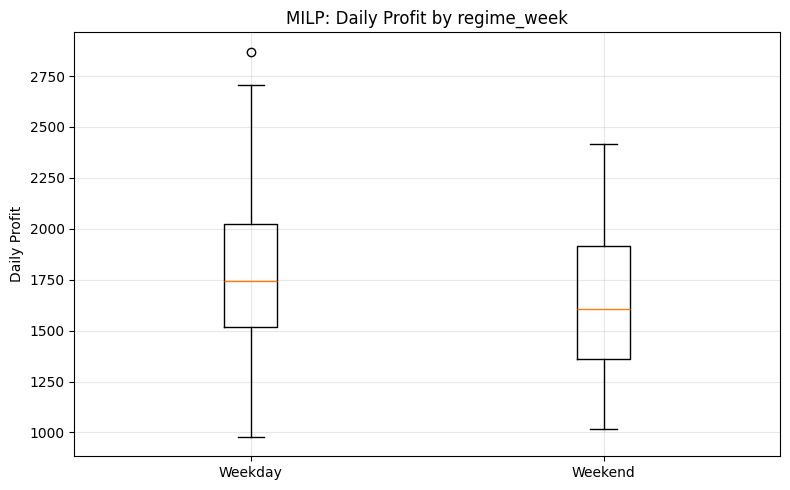

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


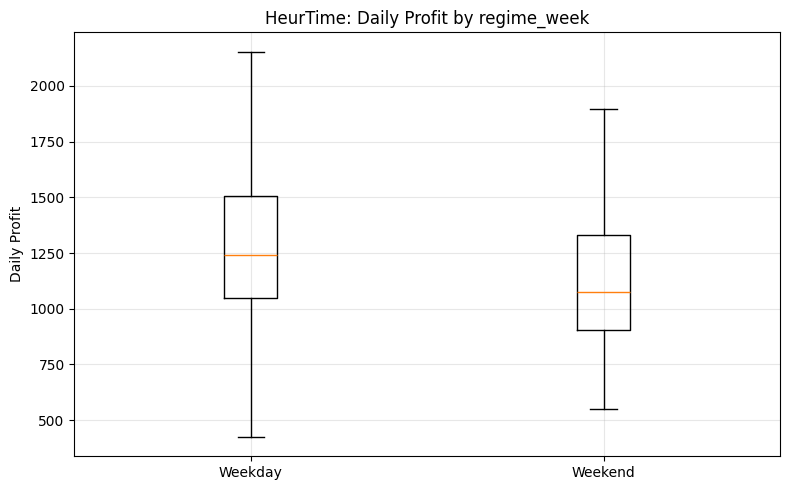

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


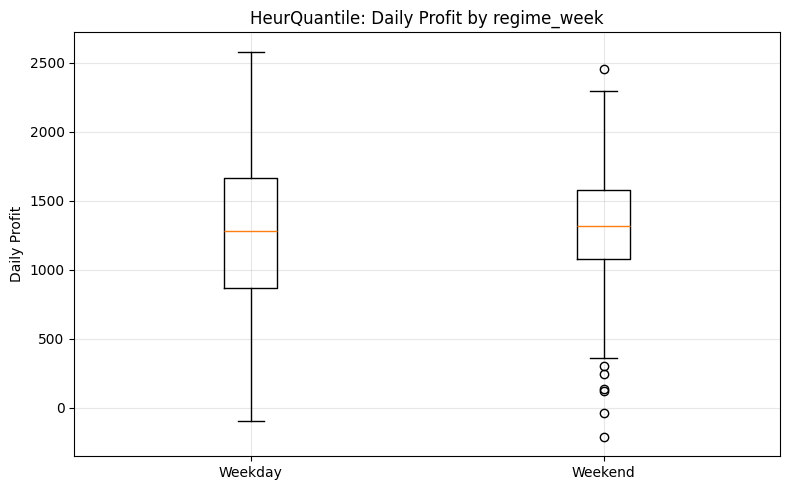

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


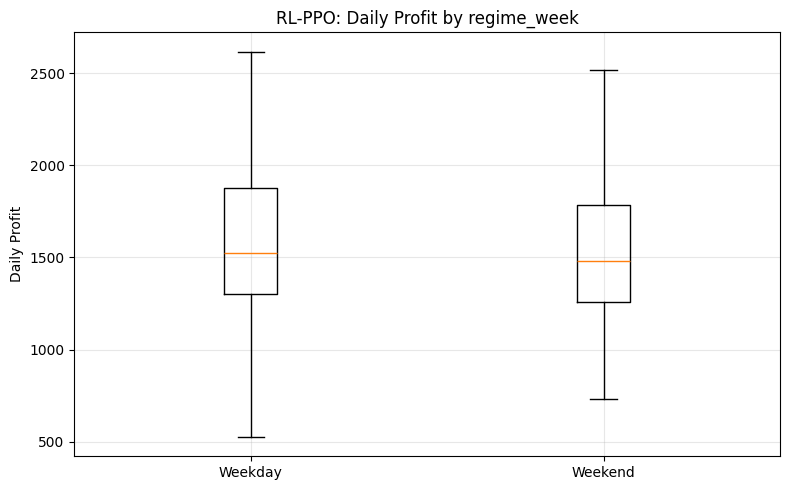

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


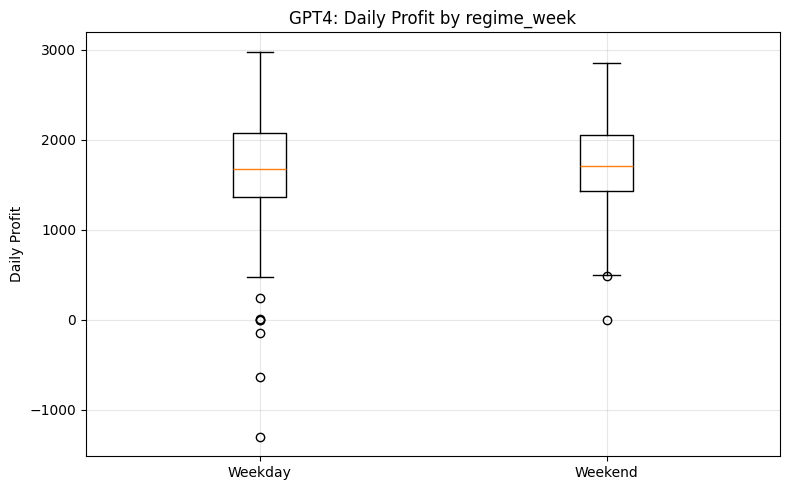

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


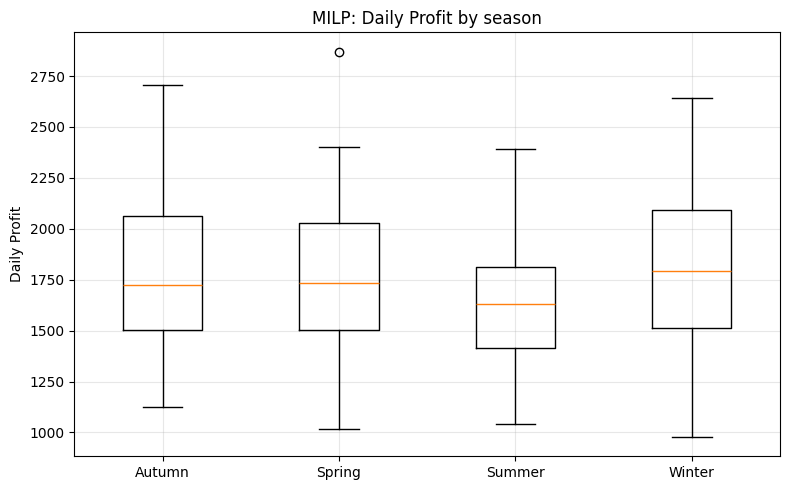

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


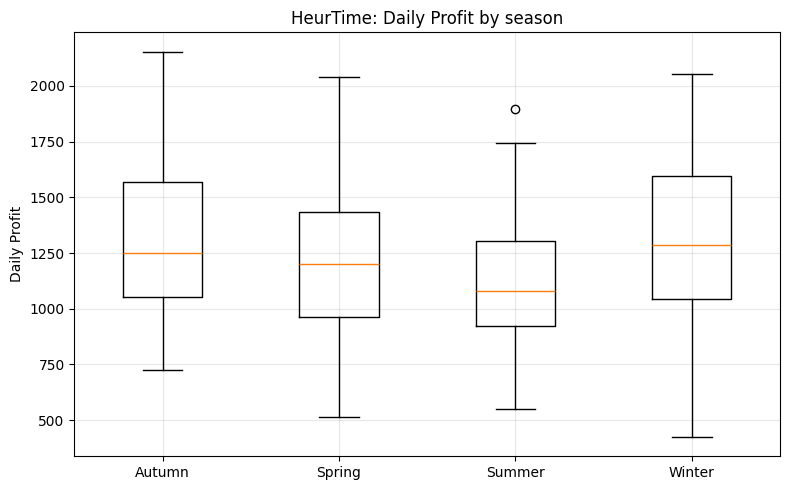

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


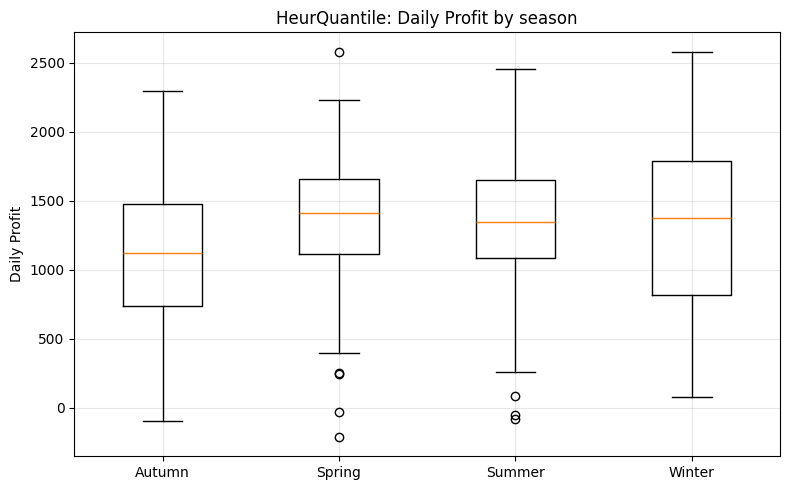

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


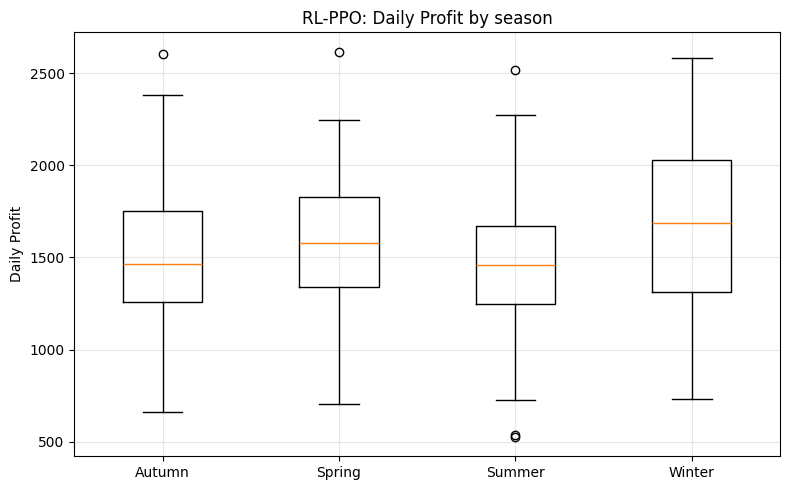

/var/folders/t4/gd0ch0vd2d9gfydnl1mwjj7c0000gn/T/ipykernel_35570/771031037.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


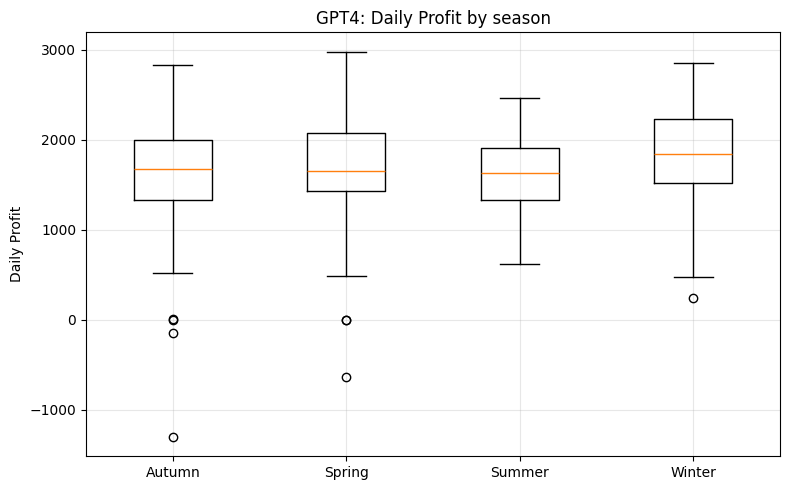

In [8]:
def plot_weekend_weekday_total_profit(week_summary):
    pivot_df = week_summary.pivot(index="method", columns="regime_week", values="total_profit")

    pivot_df.plot(kind="bar", figsize=(10, 6))
    plt.ylabel("Total Profit")
    plt.title("Weekend vs Weekday Total Profit")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_weekend_weekday_mean_profit(week_summary):
    pivot_df = week_summary.pivot(index="method", columns="regime_week", values="mean_day_profit")

    pivot_df.plot(kind="bar", figsize=(10, 6))
    plt.ylabel("Mean Daily Profit")
    plt.title("Weekend vs Weekday Mean Daily Profit")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_season_heatmap(season_summary, value_col="total_profit", title="Seasonal Profit Heatmap"):
    pivot_df = season_summary.pivot(index="method", columns="season", values=value_col)
    season_order = [s for s in ["Winter", "Spring", "Summer", "Autumn"] if s in pivot_df.columns]
    pivot_df = pivot_df[season_order]

    plt.figure(figsize=(10, 6))
    im = plt.imshow(pivot_df.values, aspect="auto")

    plt.xticks(np.arange(len(pivot_df.columns)), pivot_df.columns)
    plt.yticks(np.arange(len(pivot_df.index)), pivot_df.index)

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            plt.text(j, i, f"{pivot_df.iloc[i, j]:.1f}", ha="center", va="center")

    plt.colorbar(im, label=value_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_season_mean_profit(season_summary):
    pivot_df = season_summary.pivot(index="method", columns="season", values="mean_day_profit")
    season_order = [s for s in ["Winter", "Spring", "Summer", "Autumn"] if s in pivot_df.columns]
    pivot_df = pivot_df[season_order]

    pivot_df.plot(kind="bar", figsize=(11, 6))
    plt.ylabel("Mean Daily Profit")
    plt.title("Seasonal Mean Daily Profit")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_day_profit_boxplots(daily_all, by="regime_week"):
    methods = daily_all["method"].unique()

    for method in methods:
        g = daily_all[daily_all["method"] == method].copy()

        plt.figure(figsize=(8, 5))
        groups = [vals["day_profit"].values for _, vals in g.groupby(by)]
        labels = [name for name, _ in g.groupby(by)]

        plt.boxplot(groups, labels=labels)
        plt.ylabel("Daily Profit")
        plt.title(f"{method}: Daily Profit by {by}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_weekend_weekday_total_profit(week_summary)
plot_weekend_weekday_mean_profit(week_summary)
plot_season_heatmap(season_summary, value_col="total_profit", title="Seasonal Total Profit Heatmap")
plot_season_mean_profit(season_summary)
plot_day_profit_boxplots(daily_all, by="regime_week")
plot_day_profit_boxplots(daily_all, by="season")

